In [ ]:
# Install statsmodels if missing
import sys
!{sys.executable} -m pip install statsmodels


# Tests for variation methods
Methods (in `variation_methods.py`)
- `generate_densify_variant`
- `generate_equalize_variant`

# Setup

Imports

In [1]:
import sys
import os

# Add utils directory to path to allow imports of variation_methods and network_utils
# and to let them find their local dependencies (imports.py)
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src/net_epistemology/utils")))

import dill

import networkx as nx
import pandas as pd
import seaborn as sns
import numpy.random as rd
import statsmodels.api as sm

from IPython.display import display
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm.auto import tqdm

from variation_methods import generate_densify_variant, generate_equalize_variant
from network_utils import network_statistics

/Users/ignacio/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Load PUD network

In [2]:
with open('../../data/empirical_networks/pud_final.pkl', 'rb') as f:
    net = dill.load(f)

print(f"{net.number_of_nodes()=}")
print(f"{net.number_of_edges()=}")

net.number_of_nodes()=87
net.number_of_edges()=160


Method to generate a dataframe with network variants

In [3]:
def generate_variant_df(
    net: nx.Graph, 
    method: str,
    n_networks: int =100,
) -> pd.DataFrame:
    data = []
    for _ in tqdm(range(n_networks)):
        proportion_edges = 1/3 * rd.rand()
        n_edges = int(proportion_edges * net.number_of_edges())    
        if "equal" in method:
            net_variant = generate_equalize_variant(net, n_edges)
        elif "dens" in method:
            net_variant = generate_densify_variant(net, n_edges)
        else:
            raise ValueError(f"Unknown method {method}")
        
        info = network_statistics(net_variant)
        data.append(
            {
                "proportion_removed": proportion_edges,
                "average_degree": info["average_degree"],
                "degree_gini": info["degree_gini_coefficient"],
                "clustering": info["approx_average_clustering_coefficient"],
                "n_isolates": len(list(nx.isolates(net_variant))),
            }
        )
    return pd.DataFrame(data)   

Methods for assessing multicollinearity based on VIF and Pearson correlations

In [4]:
def VIF_interpretation(score: float) -> str:
    if score >= 5:
        return "high multicollinearity"
    elif score > 1.5:
        return "acceptable multicollinearity"
    elif score > 1:
        return "minimal multicollinearity"
    elif score == 1:
        return "no multicollinearity"
    else:
        return "something went wrong"


def compute_vif(
    df: pd.DataFrame,
    columns_corr: list[str] = ["degree_average", "degree_gini", "clustering_average"],
):
    X = df[columns_corr].copy()
    X_const = X
    X_const = sm.add_constant(X)

    vif_data = pd.DataFrame(
        {
            "variable": X_const.columns,
            "VIF": [
                variance_inflation_factor(X_const.values, i)
                for i in range(X_const.shape[1])
            ],
            "VIF interpretation": [
                VIF_interpretation(variance_inflation_factor(X_const.values, i))
                for i in range(X_const.shape[1])
            ],
        }
    )
    vif_df = pd.DataFrame(
        vif_data, 
        columns=["variable", "VIF", "VIF interpretation"])
    vif_df = vif_df[vif_df["variable"].isin(columns_corr)]
    return vif_df

def pearson_interpretation(
      score: float
) -> str:
    score_abs = abs(score)
    if score_abs == 0:
        return "no "
    elif score_abs <= 0.3:
        return "weak"
    elif score_abs <= 0.5:
        return "medium"
    elif score_abs <= 1:
        return "strong"
    else:
        return "error"

def compute_correlations(
    df: pd.DataFrame, 
    columns_corr = ["degree_average", "degree_gini",'clustering_average'],
):
    df_corr = df[columns_corr].corr(method='pearson')
    display(df_corr)
    df_corr_interpretation = df_corr.map(pearson_interpretation)
    display(df_corr_interpretation)

# Equalize

Note: Runtime is approximately 10 minutes.

In [5]:
df_equalize = generate_variant_df(net, "equalize", 1_000)

  0%|          | 0/1000 [00:00<?, ?it/s]

The cell below determines multicollinearity by calculating the VIFs and Pearson correlations. The result should be:

- Pearson correlations: all weak (except diagonal)
- VIF: all minimal multicollinearity

In [6]:
network_features = ["degree_gini",'clustering']
correlations = compute_correlations(df_equalize, columns_corr=network_features)
compute_vif(df_equalize, columns_corr=network_features)

,degree_gini,clustering
degree_gini,1.000000,-0.078879
clustering,-0.078879,1.000000


,degree_gini,clustering
degree_gini,strong,weak
clustering,weak,strong


,variable,VIF,VIF interpretation
1,degree_gini,1.006261,minimal multicollinearity
2,clustering,1.006261,minimal multicollinearity


If desired, one can inspect the following scatterplot, which should not indicate any relation between the network features.

<Axes: xlabel='clustering', ylabel='degree_gini'>

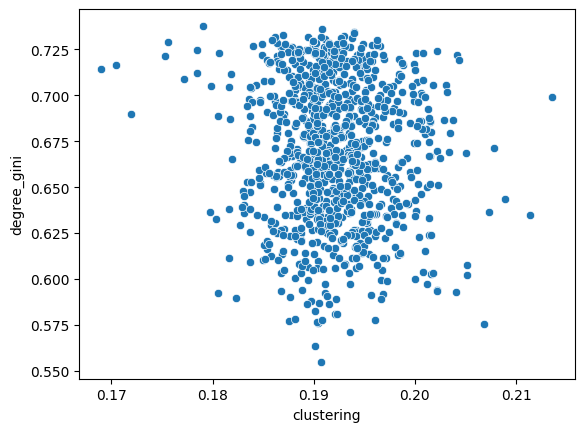

In [7]:
sns.scatterplot(df_equalize, x="clustering", y="degree_gini")

The cell below checks that there are no isolates. The result should be `True`. 

In [8]:
print(all(x == 0 for x in df_equalize["n_isolates"]))

True


# Densify

Note: Runtime is approximately 2 minutes.

In [9]:
df_densify = generate_variant_df(net, "densify", 1_000)

  0%|          | 0/1000 [00:00<?, ?it/s]

The cell below determines multicollinearity by calculating the VIFs and Pearson correlations. The result should be:

- Pearson correlations: all weak (except diagonal)
- VIF: all minimal multicollinearity

In [10]:
network_features = ["average_degree", "degree_gini",'clustering']
correlations = compute_correlations(df_densify, columns_corr=network_features)
compute_vif(df_densify, columns_corr=network_features)

,average_degree,degree_gini,clustering
average_degree,1.000000,-0.472658,0.032430
degree_gini,-0.472658,1.000000,0.084352
clustering,0.032430,0.084352,1.000000


,average_degree,degree_gini,clustering
average_degree,strong,medium,weak
degree_gini,medium,strong,weak
clustering,weak,weak,strong


,variable,VIF,VIF interpretation
1,average_degree,1.296462,minimal multicollinearity
2,degree_gini,1.304380,minimal multicollinearity
3,clustering,1.014041,minimal multicollinearity


If desired, one can check several scatterplots which should indicate no relation between the network features. 

<Axes: xlabel='average_degree', ylabel='degree_gini'>

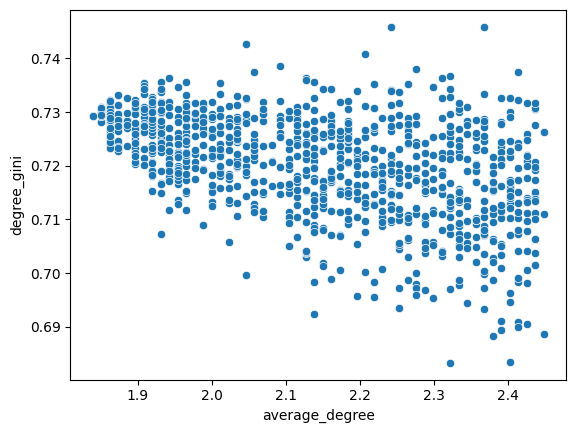

In [11]:
sns.scatterplot(df_densify, x="average_degree", y="degree_gini")

<Axes: xlabel='average_degree', ylabel='clustering'>

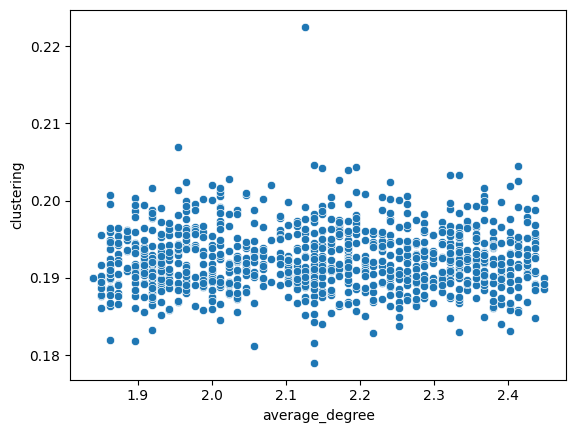

In [12]:
sns.scatterplot(df_densify, x="average_degree", y="clustering")

The cell below checks that there are no isolates. The result should be `True`. 

In [13]:
print(all(x == 0 for x in df_densify["n_isolates"]))

True
